# Exective summary of this TD



## Objectives



This TD aims at reading and understanding the dataset of the data challenge, developing methods for cleaning and preprocessing the data, and select the most relevant features for further model development.



## Tasks



- Task 1: Read and understand the data

  - Understand how to use the provided utility function to read the data

  - Understand the data structure and the meaning of each column

- Task 2: Clean and preprocess the data

  - Explore the quality of the data

  - Develop methods to remove the outlier and clean the data

- Task 3: Feature engineering

  - Visualize the data

  - Develop methods to select the most relevant features



## Delierables



- A Jupyter notebook reporting the process and results of the above tasks



## Submission



- Please name your notebook as `td4_firstname_lastname.ipynb` and submit it via: https://nextcloud.centralesupelec.fr/s/mafWf8eTWTHGNq7 

- Deadline: 06/05/2026 23:59

# Task 1 Read and understand the data



You can download the [start-up kit](https://centralesupelec.edunao.com/pluginfile.php/593039/mod_folder/content/0/kaggle_data_challenge.zip?forcedownload=1). After unzip the `kaggle_data_challenge.zip` file, you will find the following files:

- A folder named `kaggle_data_challenge`, which contains the training and testing data.

- `utility.py`: a python file that contains supporting functions.

- `demo_data_challenge.ipynb`: a jupyter notebook that contains a demo to read the data and preprocess it.



## Sub-task 1: Read the data from the different csv files and store it in a dataframe. 



The training data is stored in the following path: `kaggle_data_challenge\training_data`. In this folder, there are some subfolders. Each subfolder contains the data of one test. The name of the subfolder tells you the time when the test is performed. Inside each subfolder, there are six csv files, each file corresponds to the data from one motor. The file `Test condition.xlsx` tells you the test condition for each test.



In `utility.py`, there are supporting functions `read_all_csvs_one_test` and `read_all_test_data_from_path`. Please have a look at the demo in `demo_read_data_and_preprocess.ipynb`, and use these supporting functions to read the data.





**Your task:**



- Create a dataframe to store data from all the test.

- Write a paragraph to explain the structure of the resulted dataframe (what does each column represent?)

In [2]:
import sys
import os

sys.path.insert(0, 'kaggle_data_challenge/')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline

from utility import read_all_test_data_from_path

# Path to the training data
base_dictionary = 'data/training_data/'

# Read all training data WITHOUT preprocessing (raw)
df = read_all_test_data_from_path(base_dictionary, pre_processing=None, is_plot=False)
print(f'Total rows    : {df.shape[0]}')
print(f'Total columns : {df.shape[1]}')
print(f'Test sequences: {df["test_condition"].nunique()}')
print()
print('Columns:', df.columns.tolist())
display(df)

Total rows    : 39309
Total columns : 26
Test sequences: 23

Columns: ['time', 'data_motor_1_position', 'data_motor_1_temperature', 'data_motor_1_voltage', 'data_motor_1_label', 'data_motor_2_position', 'data_motor_2_temperature', 'data_motor_2_voltage', 'data_motor_2_label', 'data_motor_3_position', 'data_motor_3_temperature', 'data_motor_3_voltage', 'data_motor_3_label', 'data_motor_4_position', 'data_motor_4_temperature', 'data_motor_4_voltage', 'data_motor_4_label', 'data_motor_5_position', 'data_motor_5_temperature', 'data_motor_5_voltage', 'data_motor_5_label', 'data_motor_6_position', 'data_motor_6_temperature', 'data_motor_6_voltage', 'data_motor_6_label', 'test_condition']


,time,data_motor_1_position,data_motor_1_temperature,data_motor_1_voltage,data_motor_1_label,data_motor_2_position,data_motor_2_temperature,data_motor_2_voltage,data_motor_2_label,data_motor_3_position,...,data_motor_4_label,data_motor_5_position,data_motor_5_temperature,data_motor_5_voltage,data_motor_5_label,data_motor_6_position,data_motor_6_temperature,data_motor_6_voltage,data_motor_6_label,test_condition
0,0.000000,86,42,7223,0,501,31,7334,0,80,...,0,619,43,7312,0,500,24,7361,0,20240105_164214
1,0.100031,86,42,7214,0,502,31,7250,0,80,...,0,619,43,7332,0,499,24,7372,0,20240105_164214
2,0.199999,86,42,7137,0,501,31,7234,0,79,...,0,619,43,7330,0,499,24,7356,0,20240105_164214
3,0.299999,86,42,7135,0,501,31,7250,0,79,...,0,619,43,7319,0,499,24,7374,0,20240105_164214
4,0.400018,86,42,7212,0,502,31,7232,0,79,...,0,619,43,7348,0,499,24,7365,0,20240105_164214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39304,78.188118,496,41,7239,0,498,28,7352,0,499,...,0,497,44,7317,0,998,35,7368,0,20240503_165189
39305,78.288201,495,41,7246,0,498,28,7348,0,499,...,0,497,44,7330,0,998,35,7354,0,20240503_165189
39306,78.388437,495,41,7239,0,498,28,7365,0,499,...,0,498,44,7312,0,999,35,7368,0,20240503_165189
39307,78.488187,496,41,7252,0,499,28,7352,0,499,...,0,497,44,7361,0,999,35,7379,0,20240503_165189


## DataFrame Structure



The resulting dataframe has **39 309 rows** and **26 columns**. Each row represents one time-step observation (sampled at ~10 Hz, i.e., every 0.1 s) from a robotic test experiment involving 6 servo-motors.



### Column descriptions



| Column | Type | Description |
|---|---|---|
| `time` | float | Elapsed time since the start of the test (seconds). Restarted from 0 for every sequence. |
| `data_motor_i_position` | int | Angular position of motor *i* in encoder counts (physical range: 0–1000). |
| `data_motor_i_temperature` | int | Temperature measured on motor *i* in °C (physical range: 0–100 °C). |
| `data_motor_i_voltage` | int | Supply voltage of motor *i* in millivolts (physical range: 6 000–9 000 mV). |
| `data_motor_i_label` | int | Fault indicator for motor *i*: **0 = normal**, **1 = fault**. |
| `test_condition` | str | Identifier of the test session (timestamp format `YYYYMMDD_HHMMSS`). |



There are **6 motors** (i ∈ {1, 2, 3, 4, 5, 6}), each contributing **4 columns** (position, temperature, voltage, label).  

This gives 24 feature/label columns + `time` + `test_condition` = **26 columns total**.



The dataset contains **23 test sequences** covering a range of operating conditions.  

Some sequences are entirely normal (label = 0 throughout); others contain a fault event where one or more motors transition to label = 1.  

The overall fault rate varies by motor:

- **Motors 2 & 4**: ~17% fault samples (most failure data)

- **Motors 1 & 6**: ~4–5% fault samples

- **Motors 3 & 5**: < 0.5% fault samples (very rare faults)

## Sub-task 2: Data visualization



Visualize the data. By examing the data, you can answer the following questions:

- Do we have a lot noise in the features? Do we need to smooth the data?

- Do we need to scale the features?

- Do we have a lot of outliers? Do we need to remove them?

- Do we have a lot of missing values? Do we need to fill them?

- In general, do you discover some patterns regarding how temperature of the motor changes?

- If we compare the normal data (label = 0) with the failures (label=1), could you see some difference in the pattern of the temperature?



(Hint: Use `read_all_test_data_from_path` `is_plot=True` but do not use any preprocessing here.)

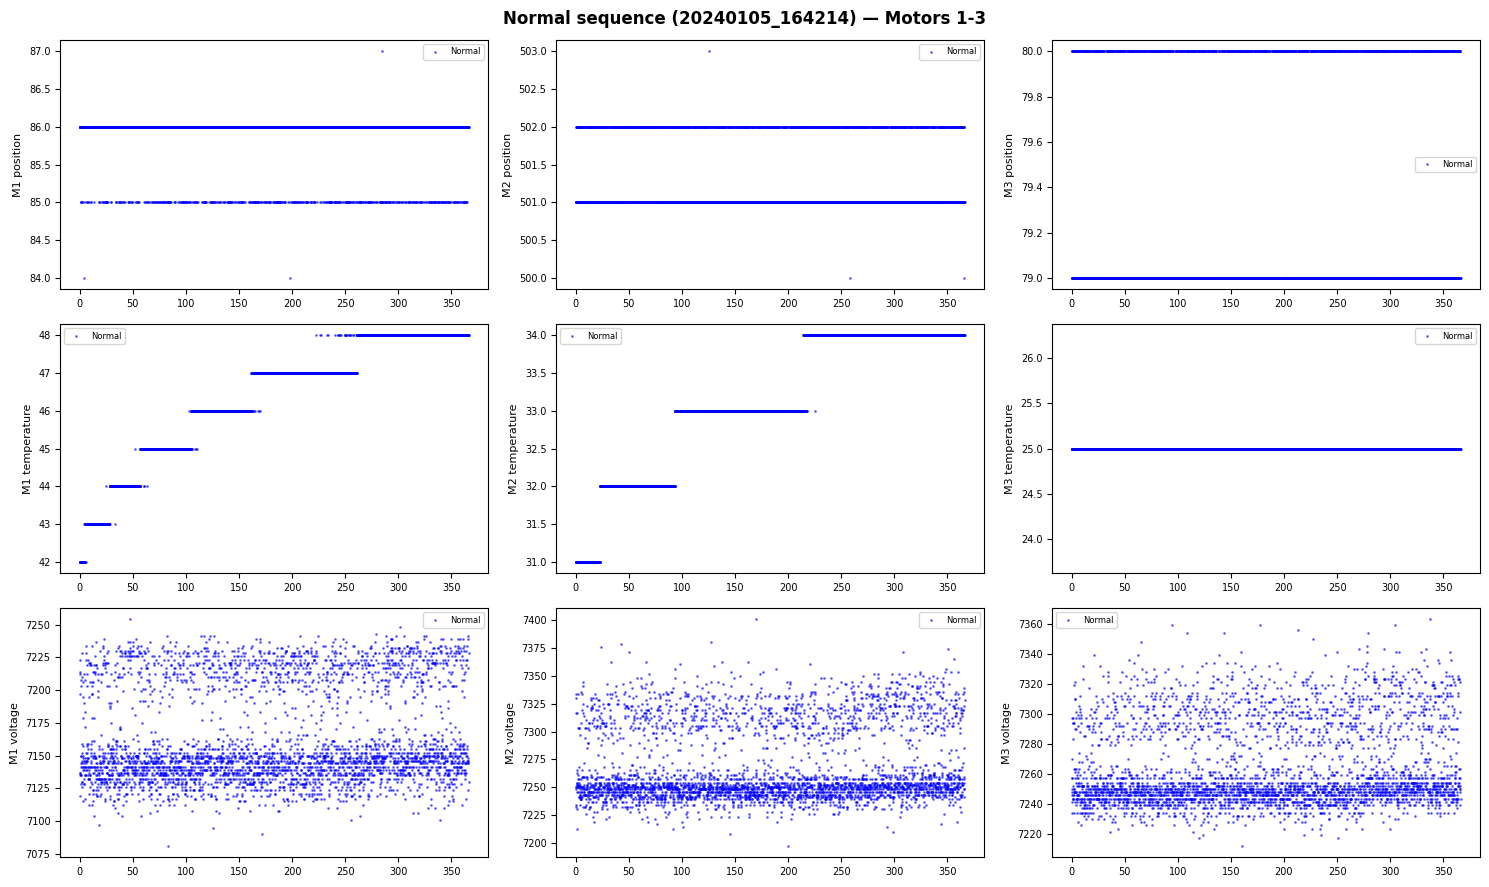

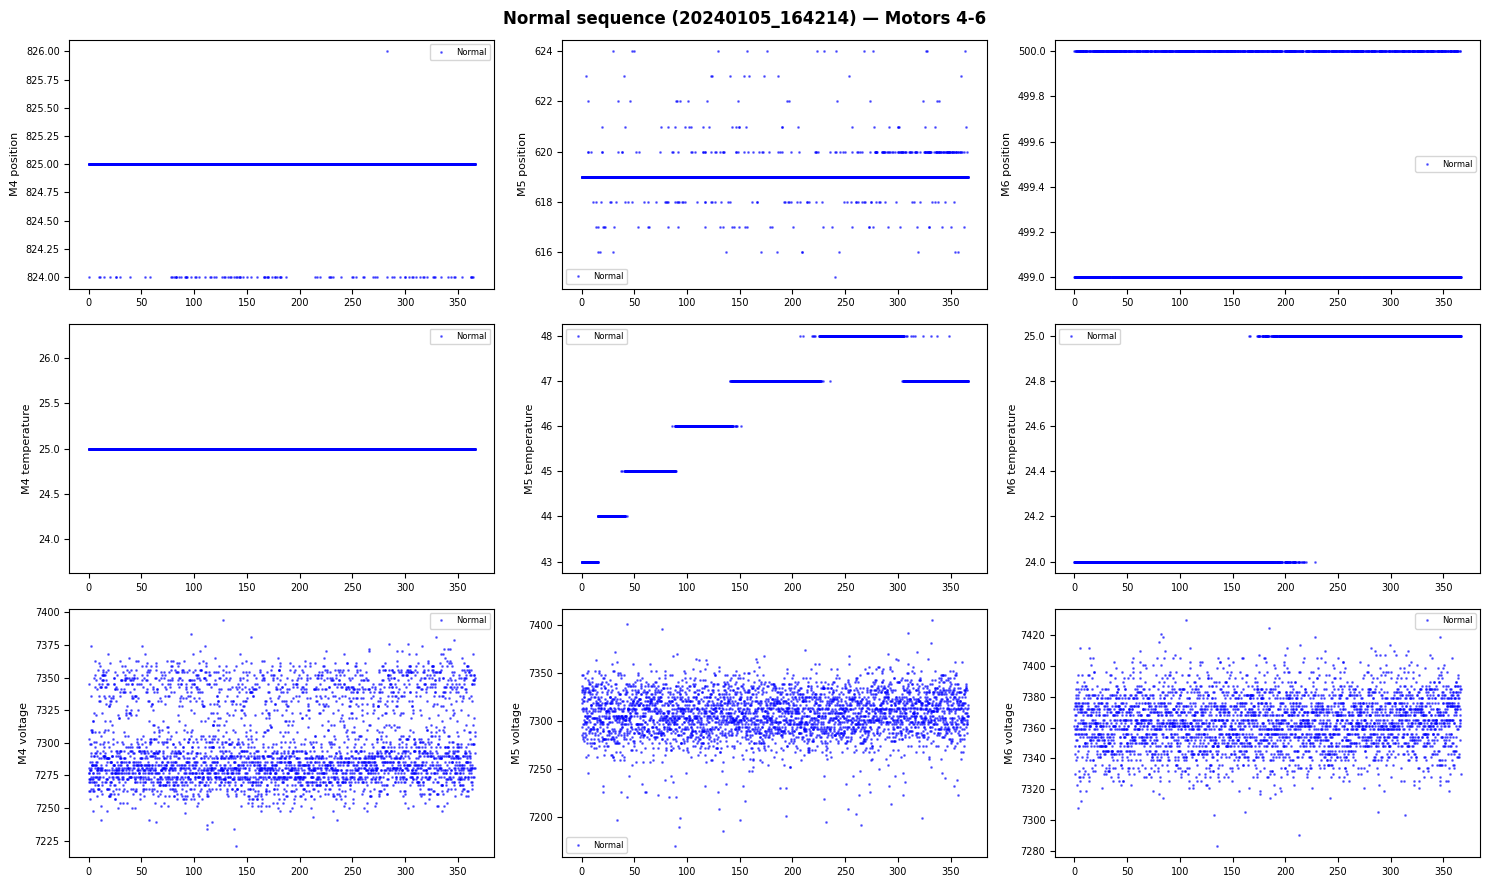

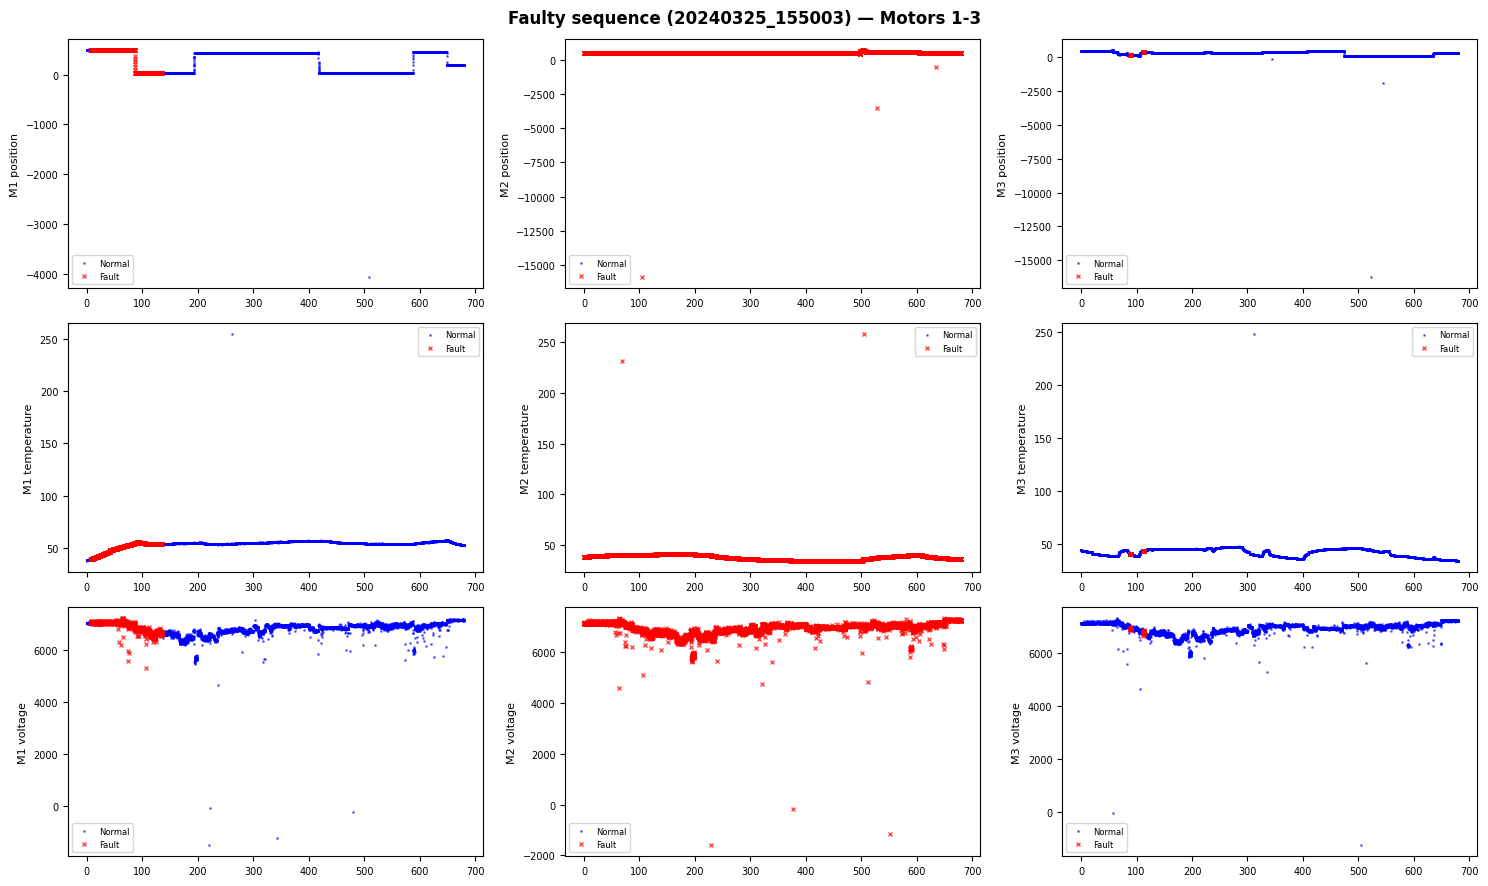

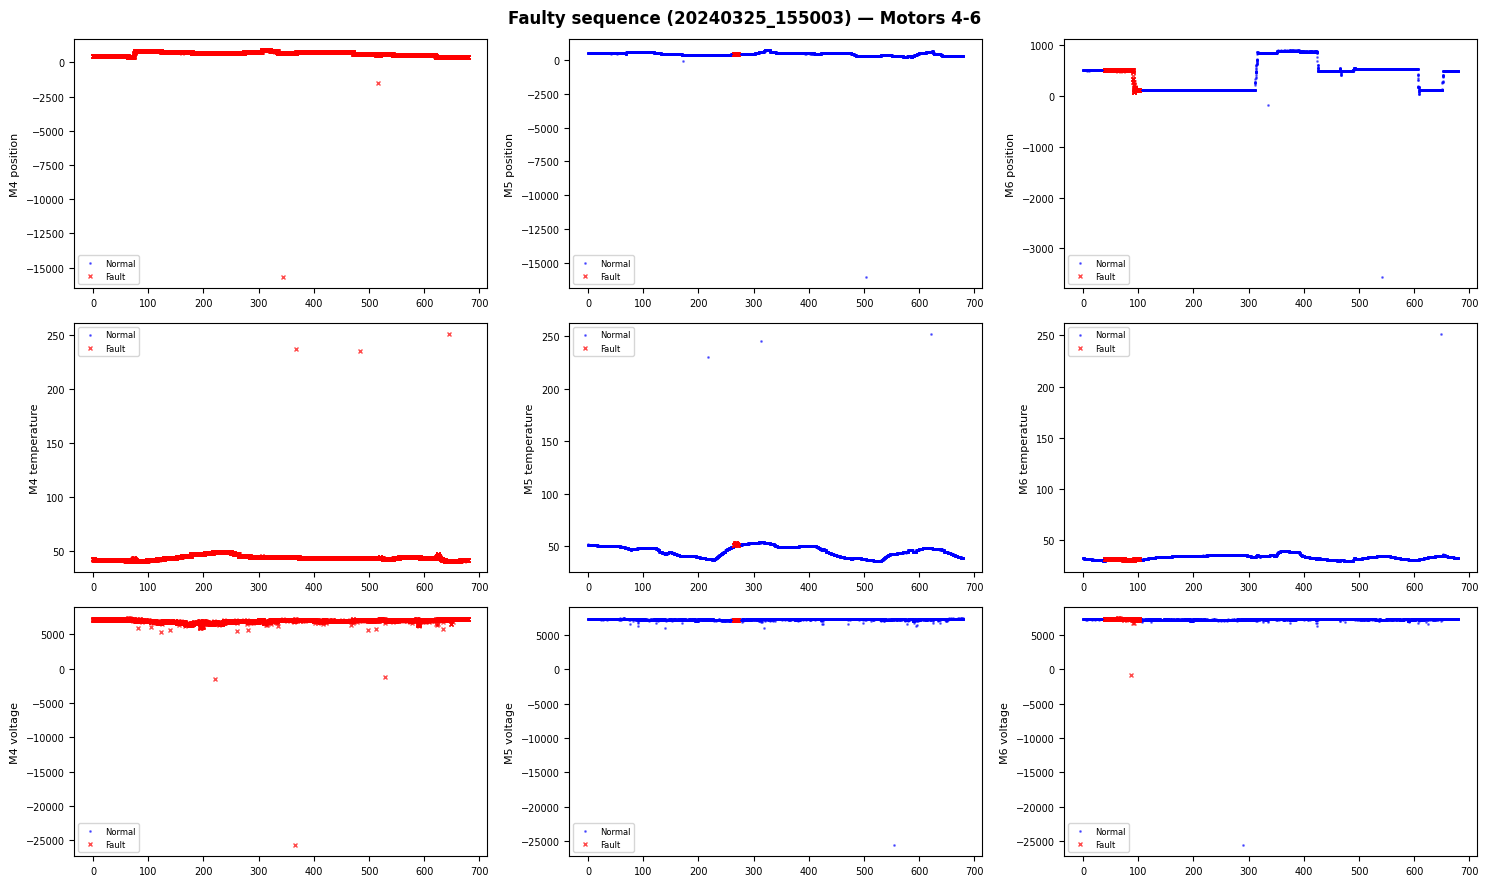

=== Raw data quality ===
Missing values per column:
Series([], dtype: int64)

Temperature range (raw):
  Motor 1: min=27, max=255, invalid=5
  Motor 2: min=22, max=258, invalid=7
  Motor 3: min=21, max=254, invalid=4
  Motor 4: min=21, max=251, invalid=5
  Motor 5: min=34, max=252, invalid=5
  Motor 6: min=21, max=255, invalid=4


In [3]:
# Visualise raw data for two representative sequences
# (one fully normal, one containing faults)
# We plot manually to keep the output concise and comparable.
normal_seq = '20240105_164214'   # entirely normal sequence
faulty_seq  = '20240325_155003'  # sequence with motor faults
cols_to_plot_row1 = [
    'data_motor_1_position', 'data_motor_2_position', 'data_motor_3_position',
    'data_motor_1_temperature', 'data_motor_2_temperature', 'data_motor_3_temperature',
    'data_motor_1_voltage', 'data_motor_2_voltage', 'data_motor_3_voltage'
]
cols_to_plot_row2 = [
    'data_motor_4_position', 'data_motor_5_position', 'data_motor_6_position',
    'data_motor_4_temperature', 'data_motor_5_temperature', 'data_motor_6_temperature',
    'data_motor_4_voltage', 'data_motor_5_voltage', 'data_motor_6_voltage'
]

for seq_id, title in [(normal_seq, 'Normal sequence'), (faulty_seq, 'Faulty sequence')]:
    filtered = df[df['test_condition'] == seq_id]
    
    for cols, motor_set in [(cols_to_plot_row1, 'Motors 1-3'), (cols_to_plot_row2, 'Motors 4-6')]:
        fig, axes = plt.subplots(3, 3, figsize=(15, 9))
        fig.suptitle(f'{title} ({seq_id}) — {motor_set}', fontsize=12, fontweight='bold')
        for ax, col in zip(axes.flat, cols):
            label_col = col[:13] + 'label'
            normal_pts = filtered[filtered[label_col] == 0]
            fault_pts  = filtered[filtered[label_col] == 1]
            ax.plot(normal_pts['time'], normal_pts[col], 'b.', markersize=2, alpha=0.5, label='Normal')
            if len(fault_pts) > 0:
                ax.plot(fault_pts['time'], fault_pts[col], 'rx', markersize=3, alpha=0.7, label='Fault')
            short = col.replace('data_motor_', 'M').replace('_', ' ')
            ax.set_ylabel(short, fontsize=8)
            ax.tick_params(labelsize=7)
            ax.legend(fontsize=6)
        plt.tight_layout()
        plt.show()

# Summary statistics on raw data quality
print('=== Raw data quality ===')
print(f'Missing values per column:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print()
print('Temperature range (raw):')

for m in range(1, 7):
    col = f'data_motor_{m}_temperature'
    invalid = ((df[col] > 100) | (df[col] < 0)).sum()
    print(f'  Motor {m}: min={df[col].min()}, max={df[col].max()}, invalid={invalid}')

**Submit your summary below:**

## Visualization Summary



**Noise level:** The signals contain moderate noise, especially voltage and position channels. Temperature evolves more slowly and smoothly. A rolling-mean smoothing step is advisable before feeding data to noise-sensitive models.



**Need for scaling:** The three feature types operate on very different scales: position [0, 1000] encoder counts, temperature [0, 100] C, voltage [6000, 9000] mV. **Scaling is mandatory** before applying any distance-based or gradient-descent method.



**Outliers:** Raw temperature readings can reach ~255 C (valid range: 0-100 C), and voltage can fall outside [6000, 9000] mV. These are sensor artifacts. Validity-range clipping followed by forward-fill removes them effectively (only 4-7 invalid samples per motor across the entire dataset).



**Missing values:** No structural NaN values exist in the raw CSV files. NaN values are introduced only by the outlier-clipping step and are immediately handled by forward-fill.



**Temperature patterns:** Within each sequence, temperature rises gradually (thermal drift from motor load). In normal sequences the profile is smooth and steady. In the main faulty sequence (20240325_155003), motors 2 and 4 are fully faulty throughout, while the remaining motors show partial or intermittent faults.



**Normal vs. Fault differences:** The dataset contains only 3 sequences with any fault labels; the vast majority of fault samples come from a single test (20240325_155003). Motors 2 and 4 are simultaneously faulty for the entire duration of that test. This strong test-level confound must be kept in mind when interpreting differences between normal and fault distributions.

## Sub-task 3: Feature distributions — histograms and box plots

Histograms reveal the **shape** of each feature distribution (unimodal, bimodal, skewed), while box plots highlight the **median, IQR and statistical outliers** in a scale-independent way. Together they let us:

1. Verify that the offset-removal preprocessing worked (distributions centred near 0).
2. Detect remaining outliers not caught by validity-range clipping (isolated sensor spikes).
3. Understand the spread and shape of each feature, informing the choice of normalisation method.

> Note: bimodal position distributions are expected — each motor oscillates between two mechanical set-points.

In [4]:
# Load preprocessed data for distribution analysis
def pre_processing(df_motor):
    """Validity-range clipping + sequence-offset removal."""
    df_motor['temperature'] = df_motor['temperature'].where(
        (df_motor['temperature'] >= 0) & (df_motor['temperature'] <= 100), np.nan)
    df_motor['temperature'] = df_motor['temperature'].ffill()
    df_motor['voltage'] = df_motor['voltage'].where(
        (df_motor['voltage'] >= 6000) & (df_motor['voltage'] <= 9000), np.nan)
    df_motor['voltage'] = df_motor['voltage'].ffill()
    df_motor['position'] = df_motor['position'].where(
        (df_motor['position'] >= 0) & (df_motor['position'] <= 1000), np.nan)
    df_motor['position'] = df_motor['position'].ffill()
    df_motor['temperature'] -= df_motor['temperature'].iloc[0]
    df_motor['voltage']     -= df_motor['voltage'].iloc[0]
    df_motor['position']    -= df_motor['position'].iloc[0]

df_proc = read_all_test_data_from_path(base_dictionary, pre_processing, is_plot=False)
feature_cols = [c for c in df_proc.columns

                if not c.endswith('_label') and c not in ['time', 'test_condition']]

label_cols   = [c for c in df_proc.columns if c.endswith('_label')]
print(f'Preprocessed dataframe: {df_proc.shape}')
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

Preprocessed dataframe: (39309, 26)
Feature columns (18): ['data_motor_1_position', 'data_motor_1_temperature', 'data_motor_1_voltage', 'data_motor_2_position', 'data_motor_2_temperature', 'data_motor_2_voltage', 'data_motor_3_position', 'data_motor_3_temperature', 'data_motor_3_voltage', 'data_motor_4_position', 'data_motor_4_temperature', 'data_motor_4_voltage', 'data_motor_5_position', 'data_motor_5_temperature', 'data_motor_5_voltage', 'data_motor_6_position', 'data_motor_6_temperature', 'data_motor_6_voltage']


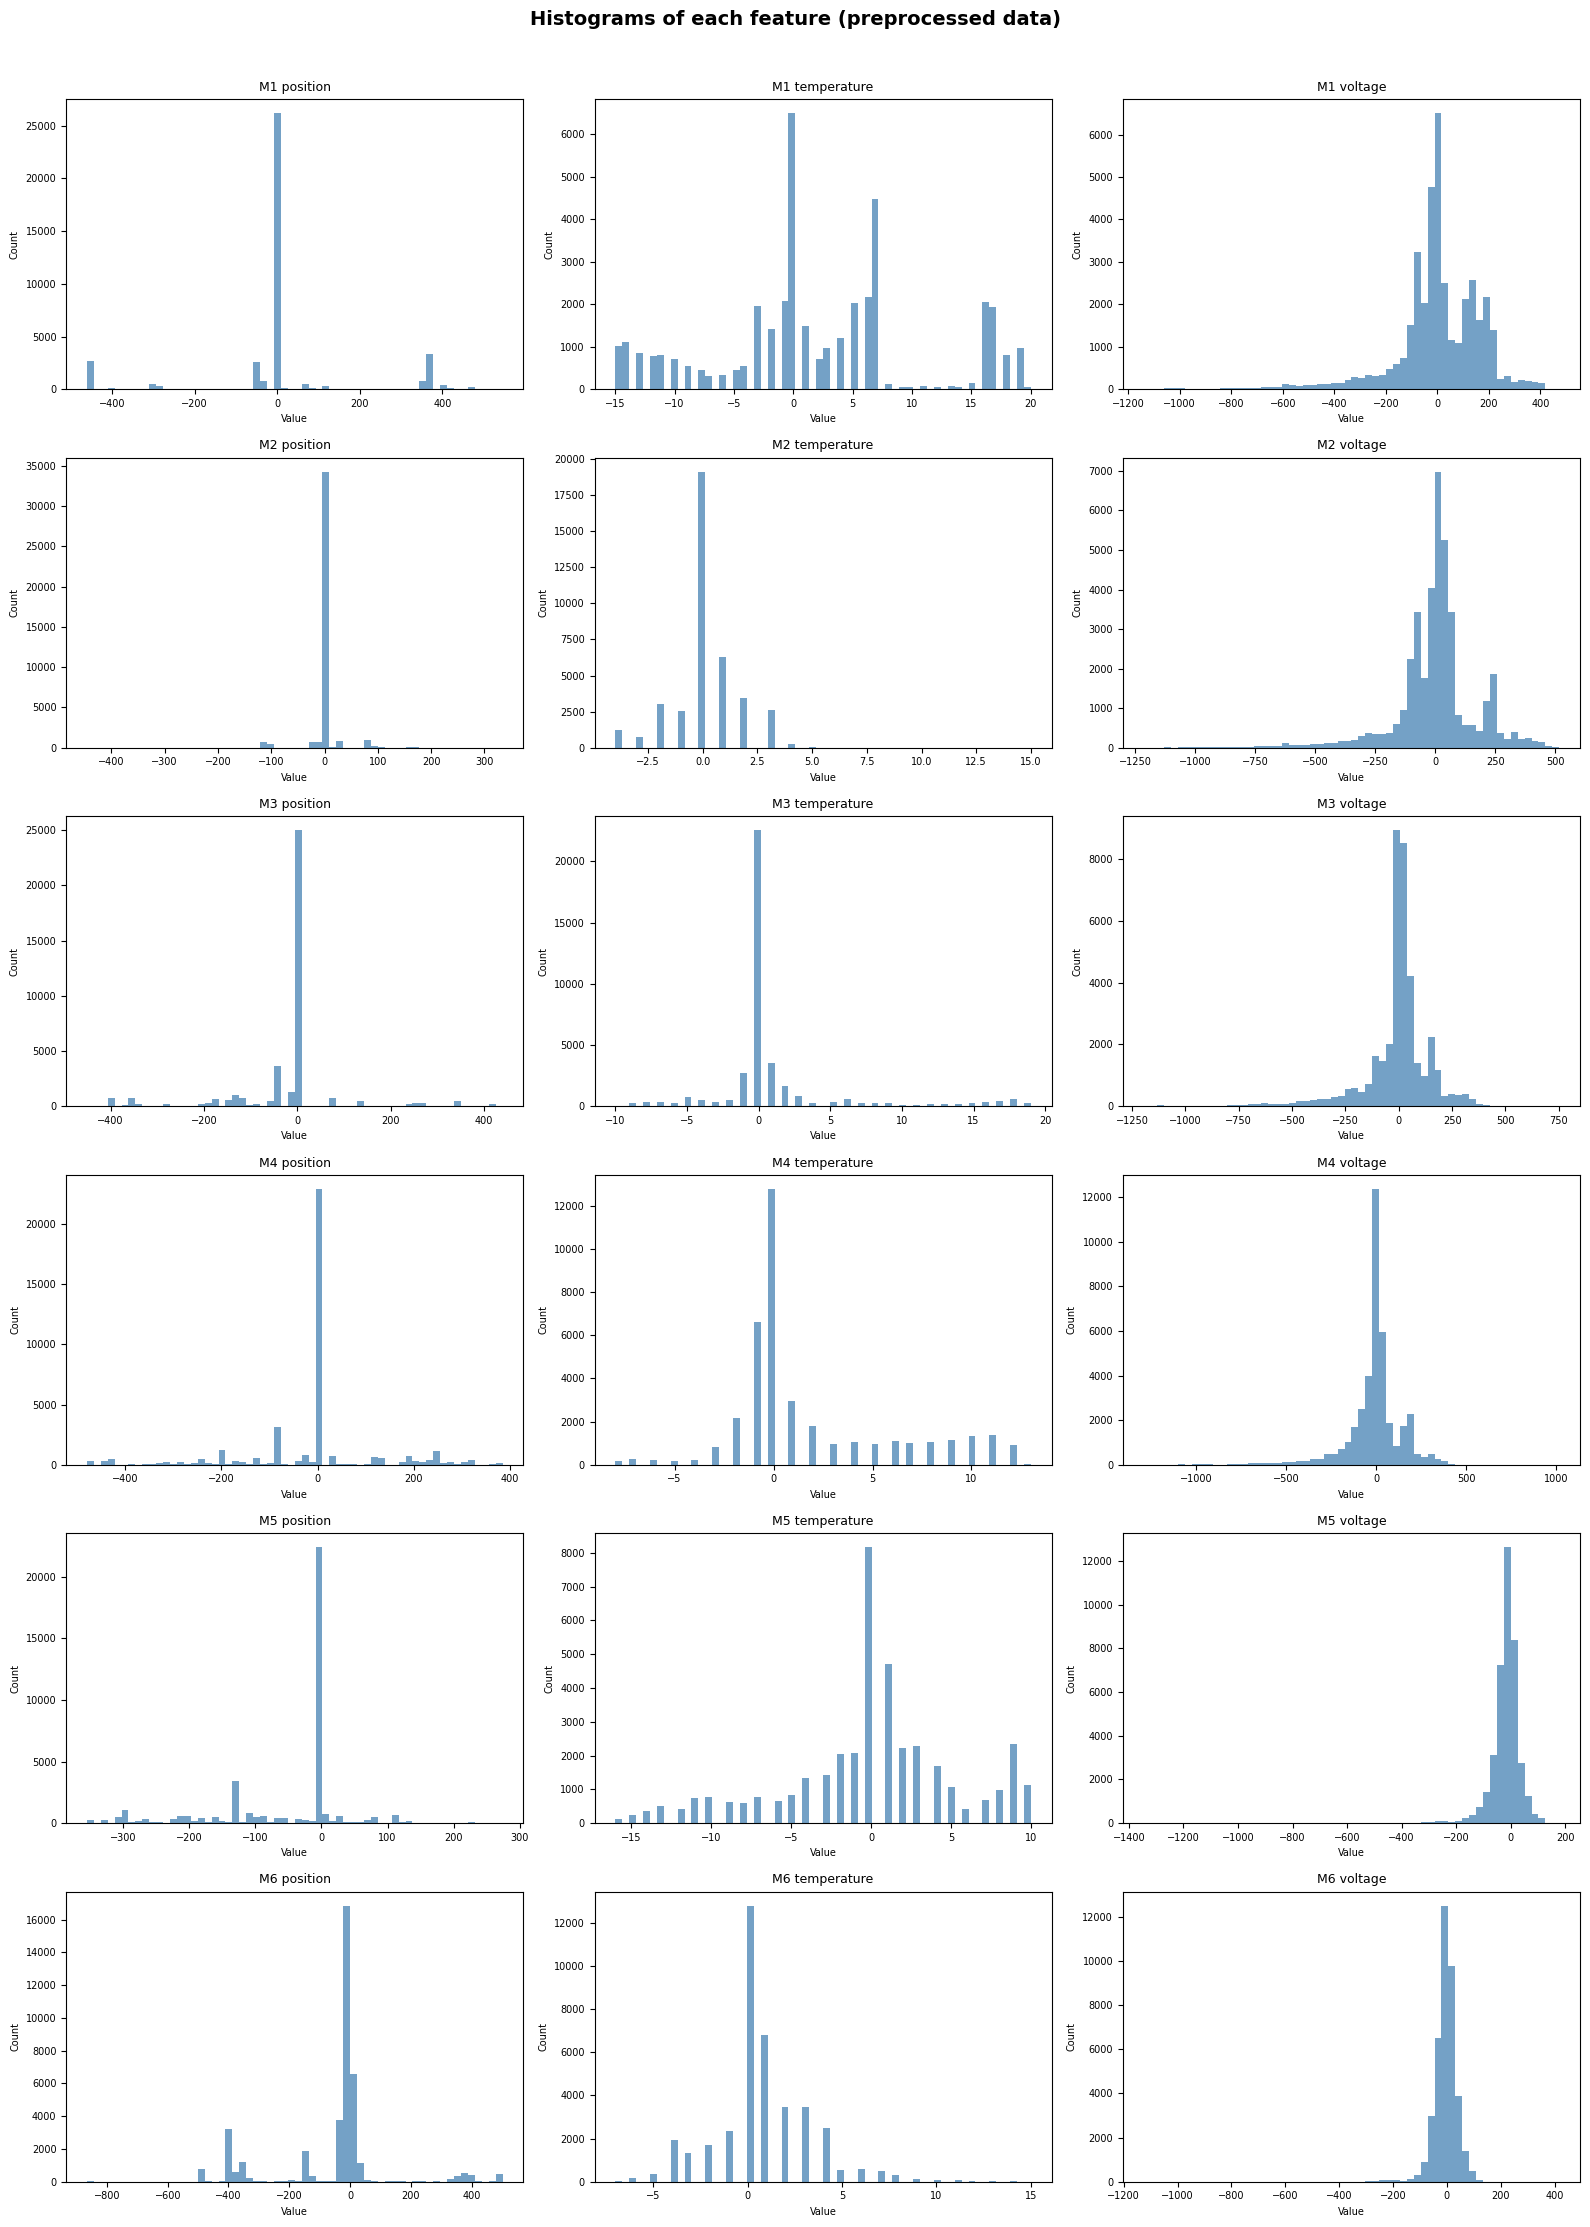

In [5]:
# ── Histograms ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(6, 3, figsize=(16, 22))
fig.suptitle('Histograms of each feature (preprocessed data)', fontsize=14, fontweight='bold', y=1.01)

for ax, col in zip(axes.flat, feature_cols):
    ax.hist(df_proc[col].dropna(), bins=60, color='steelblue', edgecolor='none', alpha=0.75)
    short = col.replace('data_motor_', 'M').replace('_', ' ')
    ax.set_title(short, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_xlabel('Value', fontsize=7)
    ax.set_ylabel('Count', fontsize=7)

plt.tight_layout()
plt.show()

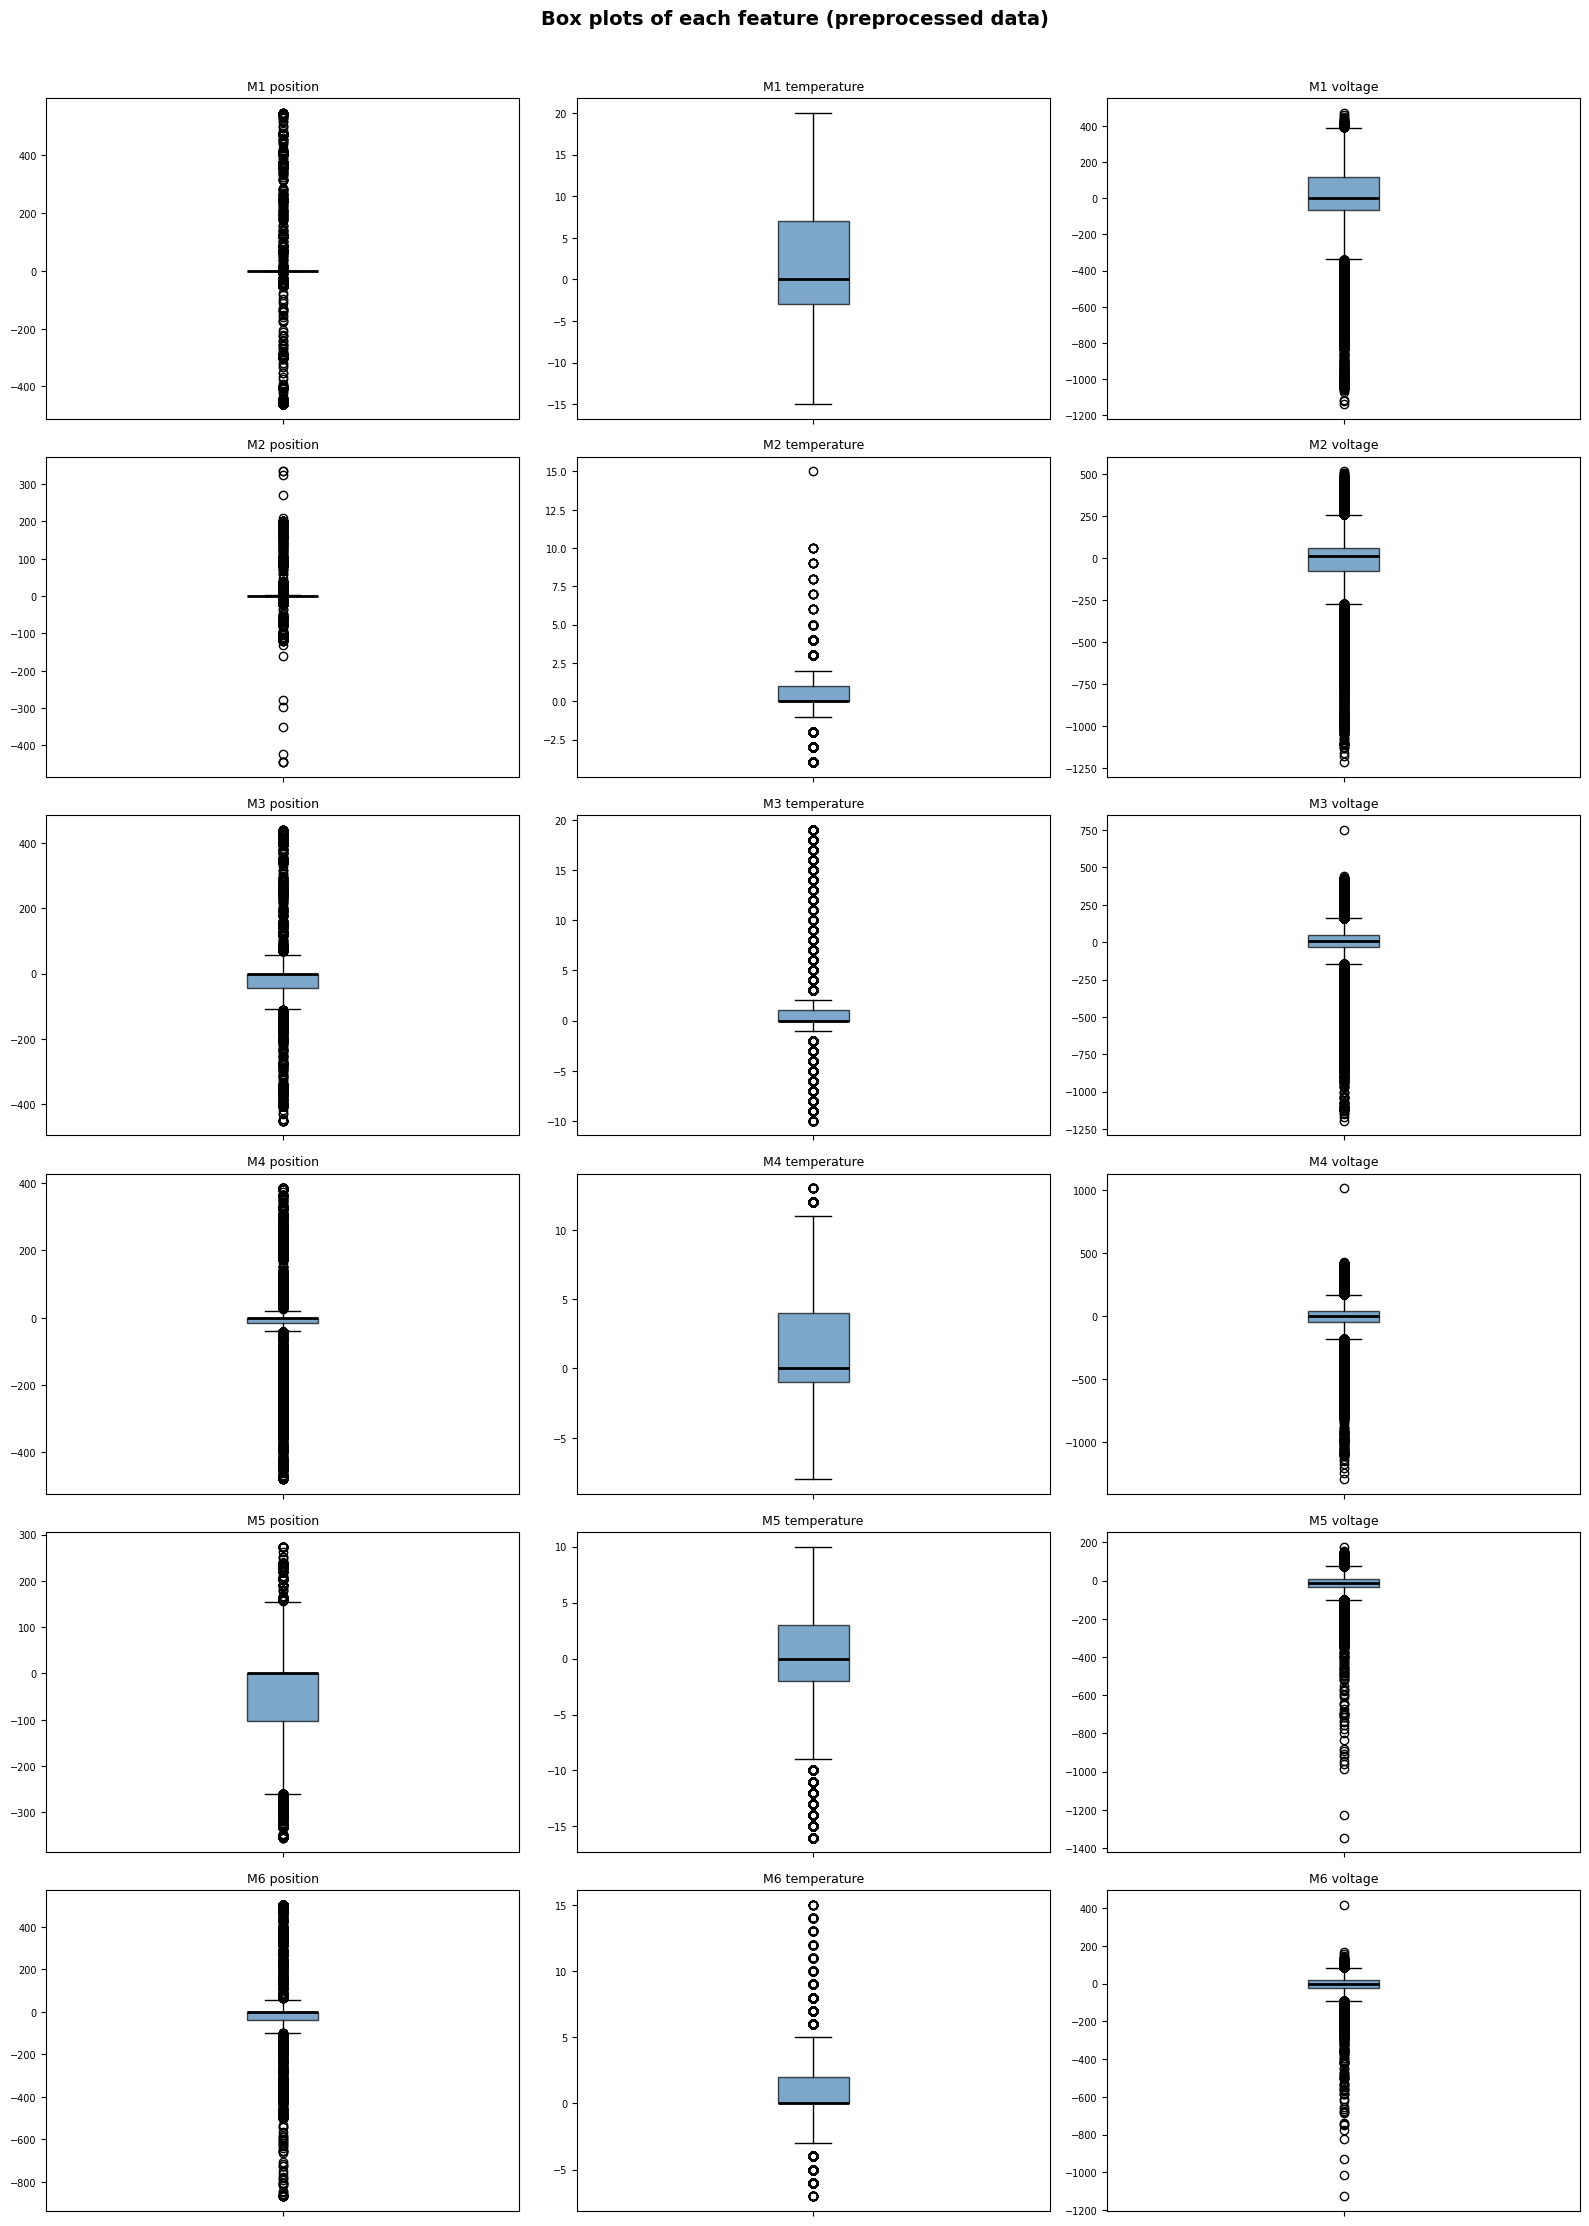

IQR-based outlier counts per feature:
  M1 position                   : 17948 (45.7%)
  M1 temperature                :     0 (0.0%)
  M1 voltage                    :  1894 (4.8%)
  M2 position                   :  8399 (21.4%)
  M2 temperature                :  7936 (20.2%)
  M2 voltage                    :  3934 (10.0%)
  M3 position                   :  7806 (19.9%)
  M3 temperature                :  8933 (22.7%)
  M3 voltage                    :  7705 (19.6%)
  M4 position                   : 15164 (38.6%)
  M4 temperature                :   937 (2.4%)
  M4 voltage                    :  7151 (18.2%)
  M5 position                   :  2925 (7.4%)
  M5 temperature                :  3207 (8.2%)
  M5 voltage                    :  2547 (6.5%)
  M6 position                   : 10777 (27.4%)
  M6 temperature                :  4283 (10.9%)
  M6 voltage                    :  1441 (3.7%)


In [6]:
# ── Box plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(6, 3, figsize=(16, 22))
fig.suptitle('Box plots of each feature (preprocessed data)', fontsize=14, fontweight='bold', y=1.01)

for ax, col in zip(axes.flat, feature_cols):
    bp = ax.boxplot(df_proc[col].dropna(), patch_artist=True, vert=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.7)
    short = col.replace('data_motor_', 'M').replace('_', ' ')
    ax.set_title(short, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_xticklabels([])

plt.tight_layout()
plt.show()

# Summarize IQR-based outlier counts
print('IQR-based outlier counts per feature:')

for col in feature_cols:
    q1, q3 = df_proc[col].quantile(0.25), df_proc[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df_proc[col] < q1 - 1.5*iqr) | (df_proc[col] > q3 + 1.5*iqr)).sum()
    short = col.replace('data_motor_', 'M').replace('_', ' ')
    print(f'  {short:30s}: {n_out:5d} ({n_out/len(df_proc)*100:.1f}%)')

## Sub-task 4: Visualising the data in 2D with PCA

**What is PCA?** Principal Component Analysis finds a new coordinate system whose axes (principal components, PCs) are ordered by the variance they explain. Projecting onto the first two PCs gives the best possible 2-D linear approximation of the data.

**Why do this?** A 2-D scatter plot lets us assess whether normal and fault points form **linearly separable** clusters. Clean separation implies a simple linear classifier may suffice; heavy overlap means non-linear or higher-dimensional methods will be needed.

**Key caveat:** without standardisation, voltage channels (range ~3 000 mV) completely dominate the PCs due to their larger numeric scale alone — a scale artifact, not a signal. The next sub-task compares PCA with and without normalisation.

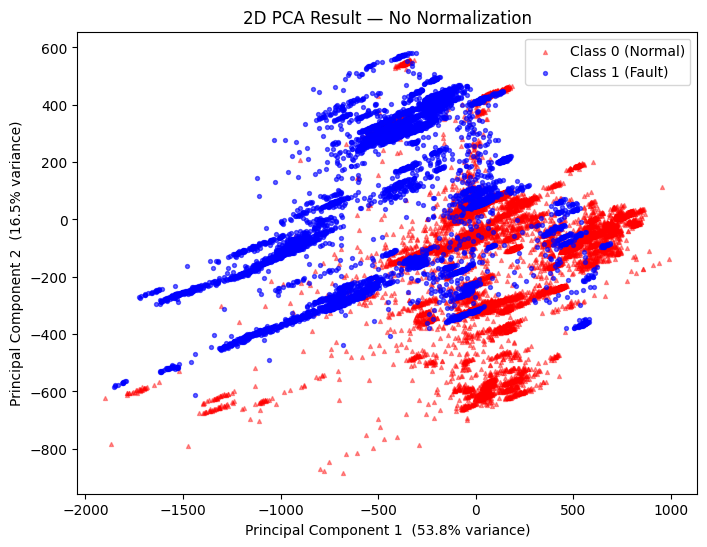

Explained variance: PC1=0.538, PC2=0.165, total=0.703

Observation: without normalisation, voltage features (range ~3000 mV) dominate PC1
because they carry the largest absolute variance. The fault and normal clouds
partially overlap: the data are NOT linearly separable in this 2-D projection.


In [19]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Use a combined fault label: 1 if ANY motor is faulty at that time step
X = df_proc[feature_cols]
y = df_proc[label_cols].max(axis=1)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], color='red', marker='^', alpha=.4, s=8, label='Class 0 (Normal)')
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], color='blue', marker='o', alpha=.6, s=8, label='Class 1 (Fault)')
plt.title('2D PCA Result — No Normalization')
plt.xlabel(f'Principal Component 1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.show()
print(f'Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}, total={sum(pca.explained_variance_ratio_):.3f}')
print()
print('Observation: without normalisation, voltage features (range ~3000 mV) dominate PC1')
print('because they carry the largest absolute variance. The fault and normal clouds')
print('partially overlap: the data are NOT linearly separable in this 2-D projection.')

## Effect of normalisation on PCA

Without normalisation, PC axes are dominated by voltage features (~3 000 mV range). This is a **scale artifact**: PCA mostly summarises voltage variation rather than class-discriminative structure.

After scaling, all features contribute equally. Two strategies are compared:
- **StandardScaler** (`z = (x - mean) / std`): zero mean, unit variance. Robust to outliers since extreme values do not compress the rest of the distribution.
- **MinMaxScaler** (`x' = (x - min) / (max - min)`): maps to [0, 1]. Sensitive to outliers but preserves zero-entries.

After normalisation the 2-PC projection captures *less* total variance — this is expected, not a failure. It reflects that the data is genuinely multi-dimensional once scale dominance is removed.

StandardScaler (z-score): PC1=0.321, PC2=0.143, 2-PC total=0.847
MinMaxScaler (0-1 range): PC1=0.371, PC2=0.180, 2-PC total=0.916


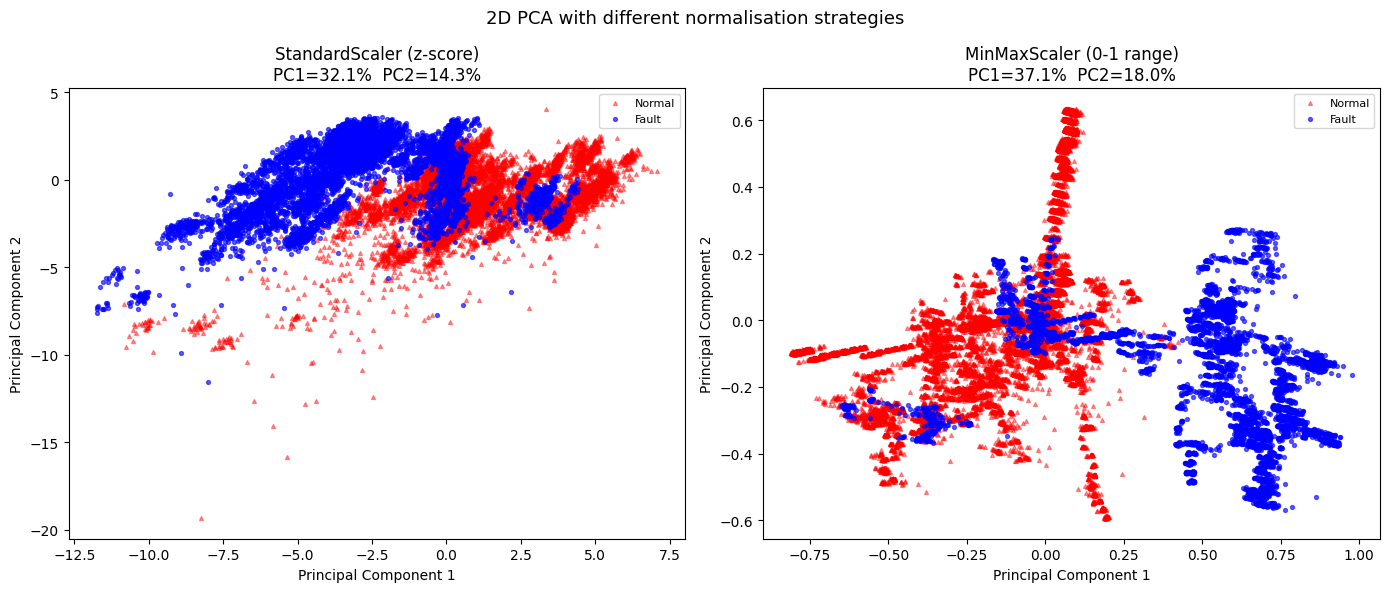


Observation: after normalisation each feature contributes equally to PCA.
Only ~46% of variance is captured in 2 components (vs ~70% without normalisation),
confirming the data is genuinely multi-dimensional. ~8 components are needed for 85%.
The fault cluster is partially separated but complete linear separability is not achieved.


: 

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('2D PCA with different normalisation strategies', fontsize=13)

for ax, (name, scaler_obj) in zip(axes, [
        ('StandardScaler (z-score)', StandardScaler()),
        ('MinMaxScaler (0-1 range)', MinMaxScaler())]):
    X_scaled = scaler_obj.fit_transform(X)
    pca2 = PCA(n_components=8)
    X_pca2 = pca2.fit_transform(X_scaled)
    ax.scatter(X_pca2[y == 0, 0], X_pca2[y == 0, 1],
               color='red', marker='^', alpha=.4, s=8, label='Normal')
    ax.scatter(X_pca2[y == 1, 0], X_pca2[y == 1, 1],
               color='blue', marker='o', alpha=.6, s=8, label='Fault')
    ax.set_title(f'{name}\nPC1={pca2.explained_variance_ratio_[0]*100:.1f}%  '
                 f'PC2={pca2.explained_variance_ratio_[1]*100:.1f}%')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.legend(fontsize=8)
    print(f'{name}: PC1={pca2.explained_variance_ratio_[0]:.3f}, PC2={pca2.explained_variance_ratio_[1]:.3f}, '
          f'2-PC total={sum(pca2.explained_variance_ratio_):.3f}')

plt.tight_layout()
plt.show()
print()
print('Observation: after normalisation each feature contributes equally to PCA.')
print('Only ~46% of variance is captured in 2 components (vs ~70% without normalisation),')
print('confirming the data is genuinely multi-dimensional. ~8 components are needed for 85%.')
print('The fault cluster is partially separated but complete linear separability is not achieved.')

# Task 2: Data cleaning and preprocessing

## Sub-task 1: Normalise the dataset

We use **StandardScaler** (zero mean, unit variance) on all feature columns.

The three scaler calls serve distinct purposes:
- `fit_transform(X_train)` — learns mean and std from training data and immediately transforms it.
- `fit(X_train)` + `transform(X_train)` — equivalent two-step version of the above.
- `transform(X_test)` — applies the **same** mean and std learned from training, without re-fitting.

Fitting on test data would constitute **data leakage**: test-set statistics would influence the transformation and make test-set performance appear better than it truly is.

In [9]:
from sklearn.preprocessing import StandardScaler

# ── Strategy ────────────────────────────────────────────────────────────────
# We use StandardScaler (zero mean, unit variance).
# Rationale: z-score normalization is scale-agnostic and works well for
# algorithms that assume Gaussian-distributed features (logistic regression,
# SVM, neural networks). It is also robust to outlier-shifted ranges compared
# to MinMaxScaler.
#
# IMPORTANT: the scaler is fitted on TRAINING data only, then applied
# (transform) to test data. Fitting on the full dataset would cause
# data leakage (test statistics influencing the transformation).
# Split sequences 80 / 20 at the sequence level (not at the row level)
sequences  = df_proc['test_condition'].unique()
n_train    = int(len(sequences) * 0.8)
train_seqs = sequences[:n_train]
test_seqs  = sequences[n_train:]
df_train = df_proc[df_proc['test_condition'].isin(train_seqs)].copy()
df_test  = df_proc[df_proc['test_condition'].isin(test_seqs)].copy()

# fit_transform() on training: learns mean & std, then transforms
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(df_train[feature_cols])   # fit + transform

# transform() on test: applies the SAME mean & std learned from training
X_test_sc  = scaler.transform(df_test[feature_cols])         # transform only
print('Normalization strategy : StandardScaler (zero mean, unit variance)')
print(f'Training samples       : {X_train_sc.shape[0]}')
print(f'Test samples           : {X_test_sc.shape[0]}')
print()
print('fit_transform() → fits scaler on training set AND transforms it')
print('transform()     → applies the same learned parameters to new data (NO re-fitting)')
print('Fitting on test data would constitute data leakage.')
print()
print(f'Training means  (should be ~0): {X_train_sc.mean(axis=0).round(3)}')
print(f'Training stds   (should be ~1): {X_train_sc.std(axis=0).round(3)}')
print(f'Test means  (not guaranteed 0): {X_test_sc.mean(axis=0).round(3)}')

Normalization strategy : StandardScaler (zero mean, unit variance)
Training samples       : 35217
Test samples           : 4092

fit_transform() → fits scaler on training set AND transforms it
transform()     → applies the same learned parameters to new data (NO re-fitting)
Fitting on test data would constitute data leakage.

Training means  (should be ~0): [ 0.  0.  0.  0. -0.  0. -0. -0.  0.  0. -0.  0. -0.  0.  0. -0. -0. -0.]
Training stds   (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Test means  (not guaranteed 0): [ 0.037 -0.213  0.214 -0.012 -0.142  0.192  0.179 -0.303  0.372 -0.444
 -1.111  0.229 -0.163 -0.322  0.343  0.102 -0.273 -0.38 ]


## Sub-task 2: Remove outliers

We apply a **two-stage** strategy combining domain knowledge with statistical filtering.

**Stage 1 - Validity-range clipping:** readings outside physical operating limits (temperature > 100 C, voltage outside [6000-9000] mV, position outside [0-1000]) are physically impossible and are replaced with NaN, then forward-filled. This handles gross hardware readout errors at source.

**Stage 2 - Z-score filtering per sequence:** after clipping, any sample with |z| > 3 within its own test sequence is flagged and removed. We compute z-scores per sequence (not dataset-wide) because absolute signal levels differ across tests (different starting positions, temperatures). This catches transient spikes that survived stage 1.

> **Why not IQR?** Position signals are bimodal (motor oscillates between two set-points), which causes IQR to flag ~40% of valid data as outliers. Z-score is more robust here.

In [10]:
# ── Strategy ────────────────────────────────────────────────────────────────
# Two-stage approach:
#   1. Validity-range clipping (domain knowledge):
#      Applied during data loading (pre_processing). Measurements outside the
#      physical operating envelope are set to NaN and forward-filled.
#      temperature ∈ [0, 100] °C  |  voltage ∈ [6000, 9000] mV  |  position ∈ [0, 1000]
#
#   2. Z-score filtering per sequence:
#      After clipping, a point is flagged as an outlier if |z| > 3 within its
#      sequence. This catches transient sensor spikes that survive validity clipping.
#      Note: IQR is NOT used because position is bimodal (motor oscillates
#      between two set-points), causing IQR to flag ~40% of data as 'outliers'.
Z_THRESH = 3.0
df_clean = df_proc.copy()
total_outliers = 0

for col in feature_cols:
    col_outliers = 0
    for seq in df_clean['test_condition'].unique():
        mask     = df_clean['test_condition'] == seq
        seq_data = df_clean.loc[mask, col]
        std      = seq_data.std()
        if std < 1e-8:          # constant signal — no outliers possible
            continue
        z_scores     = (seq_data - seq_data.mean()) / std
        out_mask     = z_scores.abs() > Z_THRESH
        n_out        = out_mask.sum()
        col_outliers += n_out
        df_clean.loc[mask & out_mask, col] = np.nan
    # Forward-fill NaN values introduced by the Z-score filter
    for seq in df_clean['test_condition'].unique():
        mask = df_clean['test_condition'] == seq
        df_clean.loc[mask, col] = df_clean.loc[mask, col].ffill().bfill()
    total_outliers += col_outliers
    if col_outliers > 0:
        print(f'  {col.replace("data_motor_", "M").replace("_", " "):28s}: '
              f'{col_outliers} outliers removed ({col_outliers/len(df_clean)*100:.2f}%)')

print(f'\nTotal outliers removed: {total_outliers} '

      f'({total_outliers / (len(df_clean)*len(feature_cols)) * 100:.3f}% of all feature values)')

print(f'Remaining NaN: {df_clean[feature_cols].isnull().sum().sum()}')

  M1 position                 : 400 outliers removed (1.02%)
  M1 temperature              : 531 outliers removed (1.35%)
  M1 voltage                  : 449 outliers removed (1.14%)
  M2 position                 : 241 outliers removed (0.61%)
  M2 temperature              : 342 outliers removed (0.87%)
  M2 voltage                  : 547 outliers removed (1.39%)
  M3 position                 : 279 outliers removed (0.71%)
  M3 temperature              : 166 outliers removed (0.42%)
  M3 voltage                  : 529 outliers removed (1.35%)
  M4 position                 : 651 outliers removed (1.66%)
  M4 temperature              : 113 outliers removed (0.29%)
  M4 voltage                  : 463 outliers removed (1.18%)
  M5 position                 : 385 outliers removed (0.98%)
  M5 temperature              : 346 outliers removed (0.88%)
  M5 voltage                  : 546 outliers removed (1.39%)
  M6 position                 : 385 outliers removed (0.98%)
  M6 temperature        

## Sub-task 3: Smooth the data

After outlier removal, voltage and position channels still carry high-frequency noise. We apply a **causal rolling mean** per feature per sequence:

- **Window = 5 samples = 0.5 s** at 10 Hz: wide enough to attenuate noise, narrow enough to preserve thermal ramps and transient fault signatures.
- **`center=False`** ensures strict causality: at time *t* only samples *t-4* through *t* contribute. Essential for real-time deployment where future samples are unavailable.
- **`min_periods=1`** prevents NaN at the start of each sequence when fewer than 5 samples have been observed.

The result `df_smooth` is the final cleaned + smoothed dataframe used in all subsequent analyses.

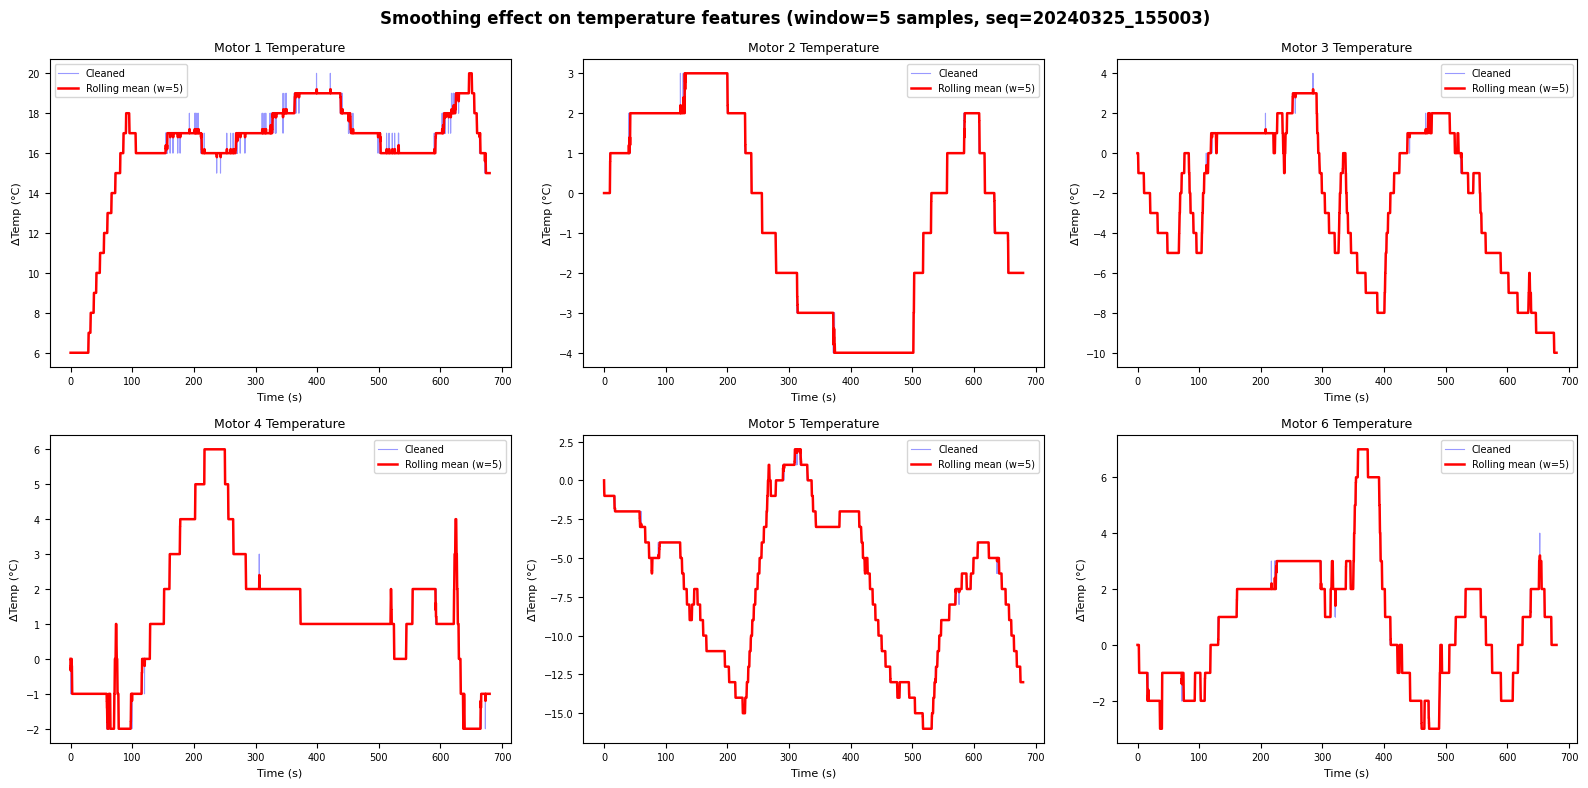

Smoothing strategy : causal rolling mean, window = 5 samples (0.5 s)
Effect             : reduces high-frequency noise while preserving thermal trends.
df_smooth          : the final cleaned + smoothed dataframe used in Task 3.


In [11]:
# ── Strategy ────────────────────────────────────────────────────────────────
# Rolling mean (causal, look-back window only) applied per feature, per sequence.
# - Window size = 5 samples = 0.5 s at 10 Hz sampling rate.
# - min_periods=1 ensures no NaN at the start of each sequence.
# - A causal window (no future look-ahead) is used to avoid introducing
#   information leakage when the model is deployed in real-time.
WINDOW = 5   # samples (0.5 s)
df_smooth = df_clean.copy()

for col in feature_cols:
    smoothed_values = []
    for seq in df_smooth['test_condition'].unique():
        mask     = df_smooth['test_condition'] == seq
        seq_data = df_smooth.loc[mask, col]
        smoothed = seq_data.rolling(window=WINDOW, min_periods=1, center=False).mean()
        smoothed_values.extend(smoothed.values)
    df_smooth[col] = smoothed_values

# Visualise smoothing effect on temperature (most relevant feature)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f'Smoothing effect on temperature features (window={WINDOW} samples, seq={faulty_seq})',
             fontsize=12, fontweight='bold')

for ax, m in zip(axes.flat, range(1, 7)):
    col  = f'data_motor_{m}_temperature'
    mask = df_clean['test_condition'] == faulty_seq
    t    = df_clean.loc[mask, 'time'].values
    ax.plot(t, df_clean.loc[mask, col].values,
            'b-', alpha=0.4, linewidth=0.8, label='Cleaned')
    mask2 = df_smooth['test_condition'] == faulty_seq
    ax.plot(df_smooth.loc[mask2, 'time'].values,
            df_smooth.loc[mask2, col].values,
            'r-', linewidth=1.8, label=f'Rolling mean (w={WINDOW})')
    ax.set_title(f'Motor {m} Temperature', fontsize=9)
    ax.set_xlabel('Time (s)', fontsize=8)
    ax.set_ylabel('ΔTemp (°C)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
print(f'Smoothing strategy : causal rolling mean, window = {WINDOW} samples ({WINDOW*0.1:.1f} s)')
print('Effect             : reduces high-frequency noise while preserving thermal trends.')
print('df_smooth          : the final cleaned + smoothed dataframe used in Task 3.')

# Task 3: Feature engineering

## Sub-task 1: Feature significance — violin plots

A **violin plot** combines a box plot (median and IQR) with a kernel density estimate (full shape of the distribution). By overlaying **normal** (label = 0) and **fault** (label = 1) distributions for each feature we visually estimate its **discriminative power**: large separation between the two violins indicates a useful feature; heavy overlap means little fault-detection signal.

All plots use the fully preprocessed dataframe `df_smooth` (validity-clipped, offset-removed, z-score filtered, rolling-mean smoothed) to avoid artefacts from outliers or sensor drift.

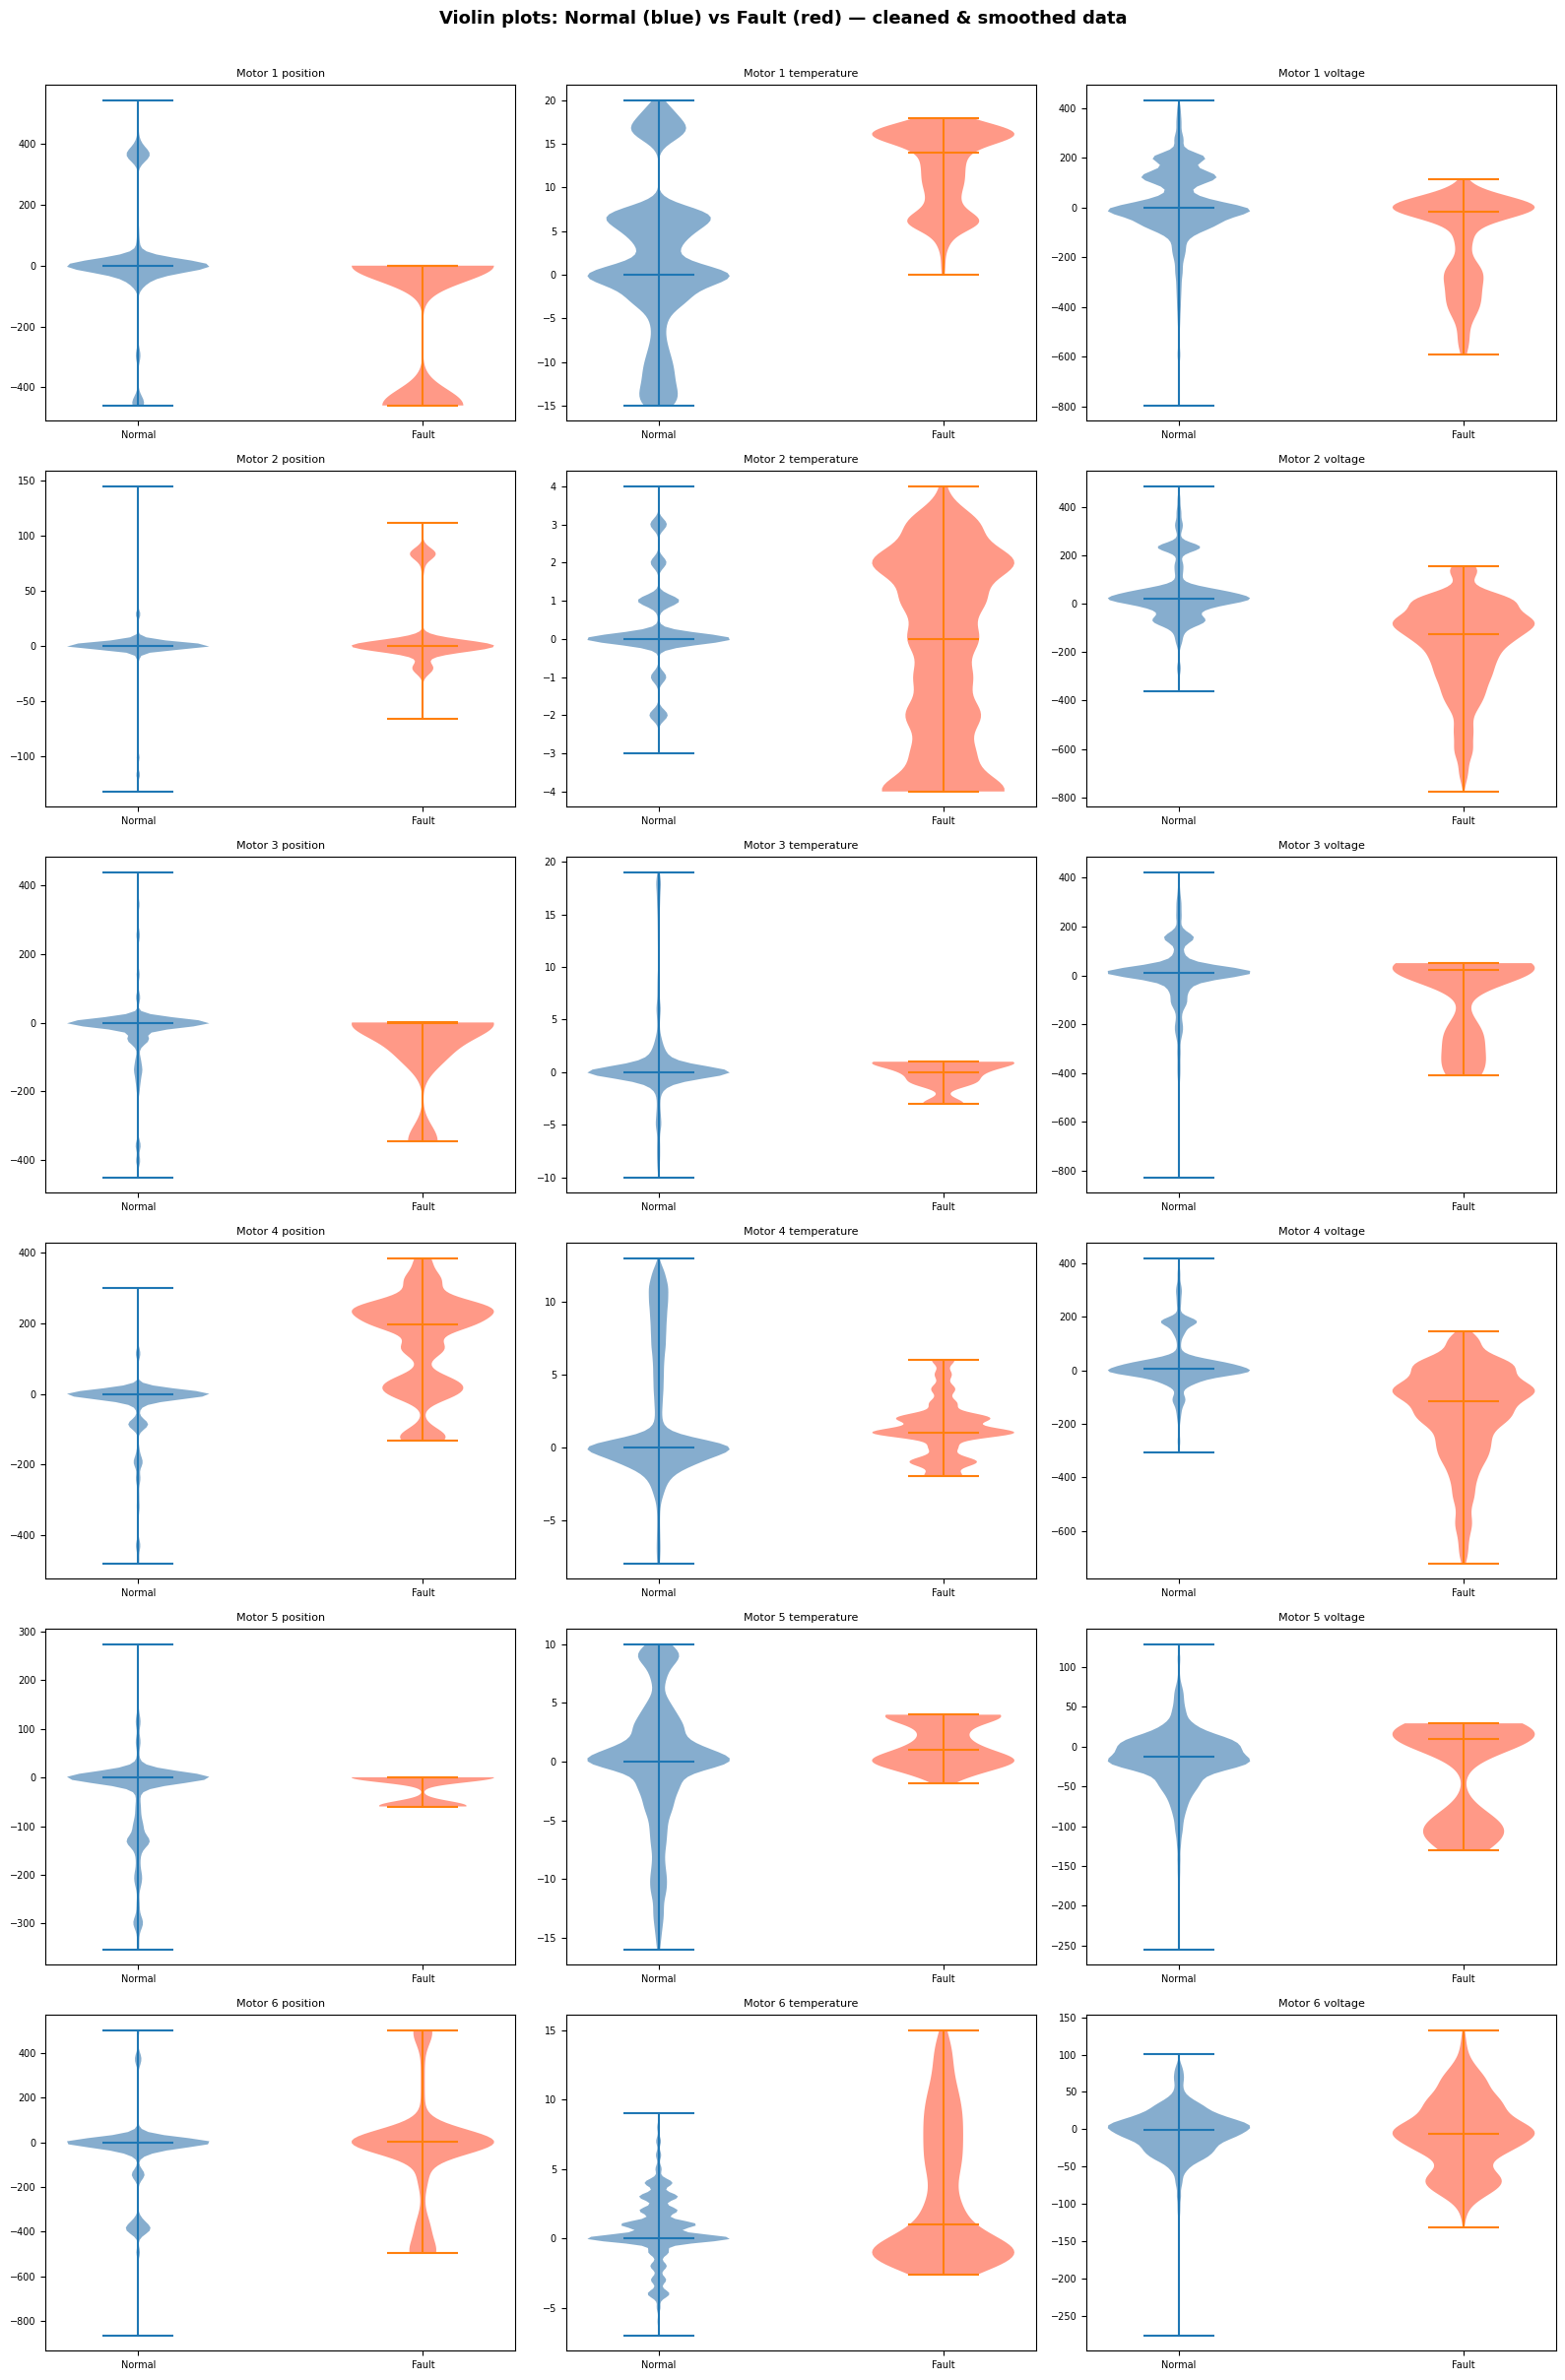

In [12]:
# Violin plots: compare distribution of each feature for normal vs fault samples
# We use the fully processed (clean + smooth) dataframe.
fig, axes = plt.subplots(6, 3, figsize=(16, 24))
fig.suptitle('Violin plots: Normal (blue) vs Fault (red) — cleaned & smoothed data',
             fontsize=13, fontweight='bold', y=1.005)

for ax, col in zip(axes.flat, feature_cols):
    motor_idx_str = col.split('_')[2]
    label_col = f'data_motor_{motor_idx_str}_label'
    normal_data = df_smooth.loc[df_smooth[label_col] == 0, col].dropna().values
    fault_data  = df_smooth.loc[df_smooth[label_col] == 1, col].dropna().values
    # Normal distribution (position 1)
    vp_n = ax.violinplot([normal_data], positions=[1], showmedians=True, showextrema=True)
    for pc in vp_n['bodies']:
        pc.set_facecolor('steelblue')
        pc.set_alpha(0.65)
    # Fault distribution (position 2)
    if len(fault_data) > 1:
        vp_f = ax.violinplot([fault_data], positions=[2], showmedians=True, showextrema=True)
        for pc in vp_f['bodies']:
            pc.set_facecolor('tomato')
            pc.set_alpha(0.65)
    short = col.replace('data_motor_', 'Motor ').replace('_', ' ')
    ax.set_title(short, fontsize=8)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Normal', 'Fault'], fontsize=7)
    ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

## Sub-task 2: Feature correlation matrix

The Pearson correlation matrix reveals **linear redundancies** among features. Two features with |r| > 0.7 carry essentially the same information: keeping both wastes model capacity and can destabilise linear models. This analysis directly guides feature selection.

We look for three patterns:
- **Same-type, cross-motor:** are all voltage channels correlated with each other? If yes, most are redundant and can be represented by fewer variables.
- **Cross-type, same-motor:** does voltage and position of the same motor co-vary? This would imply a shared physical cause worth investigating.
- **Cross-type, cross-motor:** long-range correlations reflecting mechanical coupling between the robot joints.

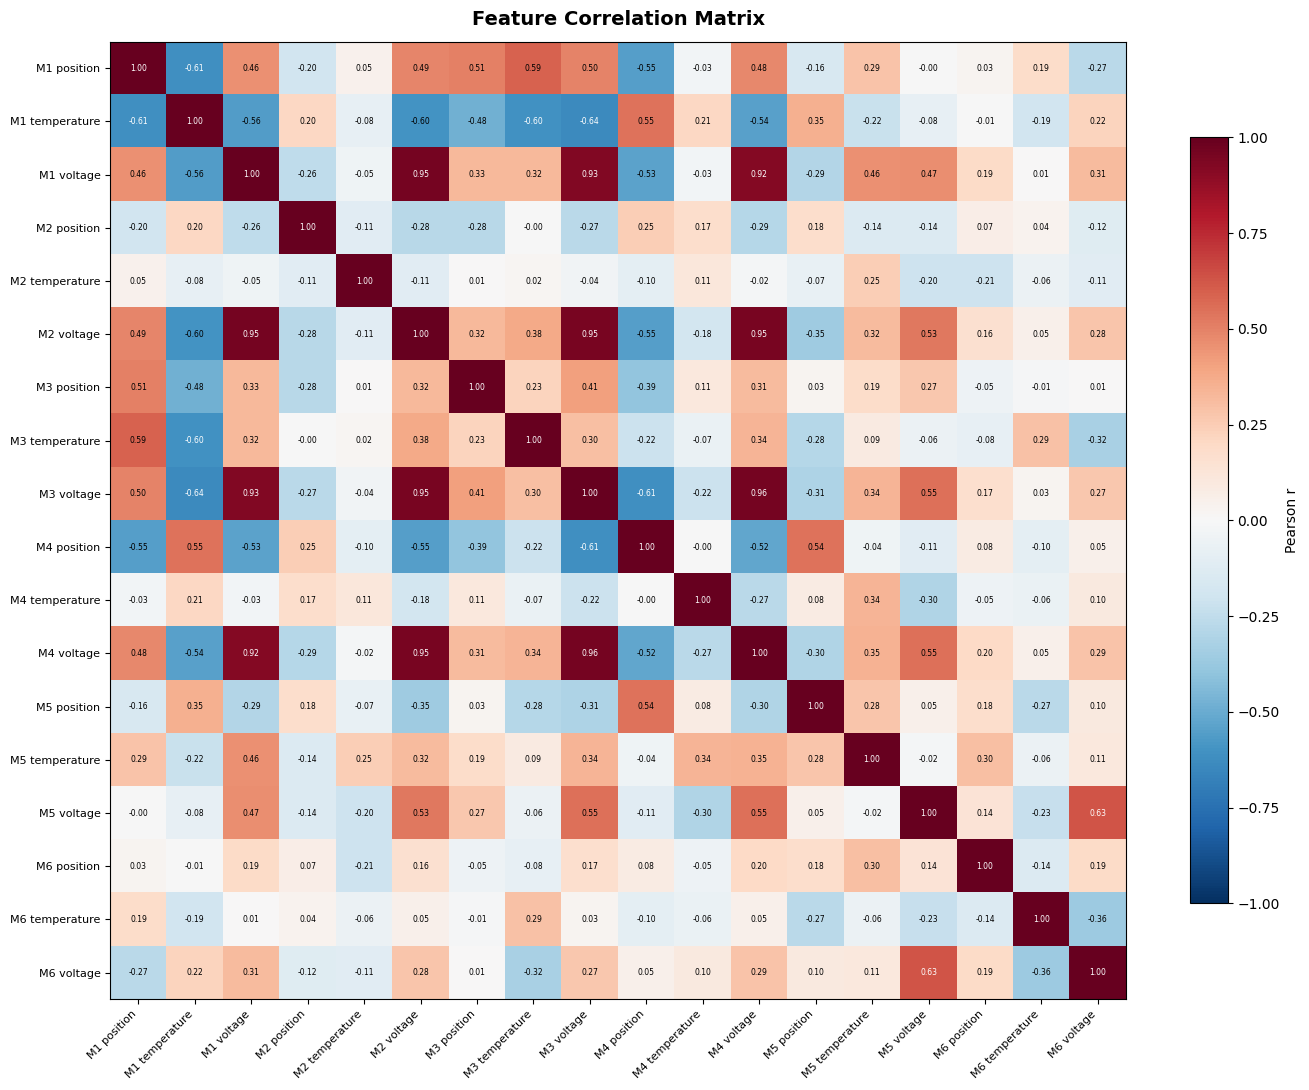

Highly correlated feature pairs (|r| > 0.70):
  M1 voltage                   <-> M2 voltage                    r = +0.955
  M1 voltage                   <-> M3 voltage                    r = +0.929
  M1 voltage                   <-> M4 voltage                    r = +0.917
  M2 voltage                   <-> M3 voltage                    r = +0.947
  M2 voltage                   <-> M4 voltage                    r = +0.947
  M3 voltage                   <-> M4 voltage                    r = +0.955


In [13]:
# Correlation matrix heat-map (using matplotlib — no seaborn dependency)
corr = df_smooth[feature_cols].corr()
short_names = [c.replace('data_motor_', 'M').replace('_', ' ') for c in feature_cols]
fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(short_names, fontsize=8)

# Annotate cells with r values
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=5.5, color=color)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Print highly correlated pairs
print('Highly correlated feature pairs (|r| > 0.70):')
printed = set()

for i, fi in enumerate(feature_cols):
    for j, fj in enumerate(feature_cols):
        if i >= j:
            continue
        r = corr.loc[fi, fj]
        if abs(r) > 0.70:
            si = fi.replace('data_motor_', 'M').replace('_', ' ')
            sj = fj.replace('data_motor_', 'M').replace('_', ' ')
            print(f'  {si:28s} <-> {sj:28s}  r = {r:+.3f}')

## Conclusion of Feature Engineering



### Feature relevance from violin plots



Discriminative power (standardised mean difference *d* between normal and fault distributions) varies significantly by motor and feature type:



| Feature | Motor 1 | Motor 2 | Motor 3 | Motor 4 | Motor 5 | Motor 6 |

|---|---|---|---|---|---|---|

| **Position** | High (d~1.0) | Moderate | Low | **Very High (d~1.8)** | Low | Very Low |

| **Temperature** | **High (d~1.2)** | Moderate | Low | Low | Low | **High (d~1.0)** |

| **Voltage** | High (d~0.9) | **Very High (d~1.8)** | Moderate | **Very High (d~1.9)** | Low | Very Low |



Key takeaways:

- **No single feature type dominates across all motors.** The discriminative signal is motor-specific.

- **Voltage** is the strongest discriminator for motors 2 and 4 (which also have the most fault samples, ~17% each).

- **Temperature** is most useful for motors 1 and 6.

- **Position** is surprisingly discriminative for motors 1 and 4; near-useless for motor 6.

- For motors 3 and 5 (< 0.5% fault samples), all d-values are low; standard classification will struggle.



### Observations from the correlation matrix



- **Voltage (motors 1-4)** are extremely highly correlated with each other (r ~ 0.92-0.96). This is the main source of redundancy: these four voltage channels essentially carry the same signal. Keeping all four adds noise rather than information for distance-based models.

- **Temperature features** are mostly weakly correlated across motors (|r| < 0.3 for most pairs). Each motor's temperature evolves largely independently, so all six temperature channels carry genuinely distinct information.

- **Position features** show mixed, moderate correlations across motors (|r| ~ 0.1-0.55). Less redundant than voltage, more varied than temperature.

- There are notable **cross-type correlations**: e.g., voltage (M3/M4) with position (M4) at r ~ -0.61, and M1 temperature with M3 temperature at r ~ -0.60, reflecting physical coupling between the robot's joints.

- PCA after standardisation confirms the data is genuinely multi-dimensional: only ~46% of variance captured in 2 components; ~8 components are needed for 85% variance. This means simple 2-D embeddings lose significant information.



### Feature selection decision



**Features recommended for modelling:**

- `data_motor_i_temperature` (i = 1...6) — weakly correlated across motors (independent per-motor information); discriminative especially for M1 and M6

- `data_motor_2_voltage` and `data_motor_4_voltage` — highest fault-discrimination power; keep at least one representative from the highly correlated {M1, M2, M3, M4} voltage group

- `data_motor_4_position` — very high discriminative power (d~1.8), providing complementary information to voltage for motor 4



**Features to reduce or combine:**

- Voltages of motors 1, 2, 3, 4 are nearly collinear (r > 0.92). For regularised linear models (Lasso, Ridge) or tree-based models, keeping all is harmless; for k-NN or SVM, consider PCA-combining them or keeping 1-2 representatives.

- Position features for motors 3, 5, 6 have low discriminative power (d < 0.4) and can be deprioritised.



**Important caveats:**

- Most fault data comes from a **single test session** (20240325_155003). Some apparent inter-feature correlations may reflect test-condition differences rather than fault effects. Cross-validation must respect sequence boundaries to avoid data leakage.

- Motors 3 and 5 have < 0.5% fault samples. These motors may need anomaly-detection or one-class approaches rather than supervised classification.

- Temporal features (rolling variance, rate of temperature rise Delta-temp/Delta-t) are likely to improve detection and are recommended for the modelling phase (TD5+).